In [2]:
import json
import numpy as np

fp = open("../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold0.8_K10_size1000.json")
data = json.load(fp)
fp.close()
fps = np.array(data["raw"]["pri_fusion_size"])
ex = np.array(data["raw"]["ex"])
ex_pub = np.array(data["raw"]["ex_pub"])
ex_pri = np.array(data["raw"]["ex_pri"])
f1 = np.array(data["raw"]["f1"])
f1_pub = np.array(data["raw"]["f1_pub"])
f1_pri = np.array(data["raw"]["f1_pri"])

In [6]:
fps = fps.reshape(2, -1, 1000)
flops = fps.sum(-1) * 768 

print(f"ex:\n {ex[1:].reshape(2, 5)}")
print(f"ex(%):\n {(ex / ex[0])[1:].reshape(2, -1).round(4) * 100}")
print(f"ex_pub(%):\n {(ex_pub / ex[0]).reshape(2, -1).round(4) * 100}")
print(f"ex_pri(%):\n {(ex_pri / ex[0]).reshape(2, -1).round(4) * 100}")

ex:
 [[0.409 0.392 0.389 0.403 0.411]
 [0.403 0.404 0.415 0.416 0.415]]
ex(%):
 [[97.85 93.78 93.06 96.41 98.33]
 [96.41 96.65 99.28 99.52 99.28]]
ex_pub(%):
 [[95.93 86.36 75.84 57.18 32.78]
 [95.93 86.36 75.84 57.18 32.78]]
ex_pri(%):
 [[32.06 61.96 82.78 89.95 96.65]
 [32.3  67.7  87.08 93.06 98.33]]


[0.73 2.45 6.36 5.38 0.  ]


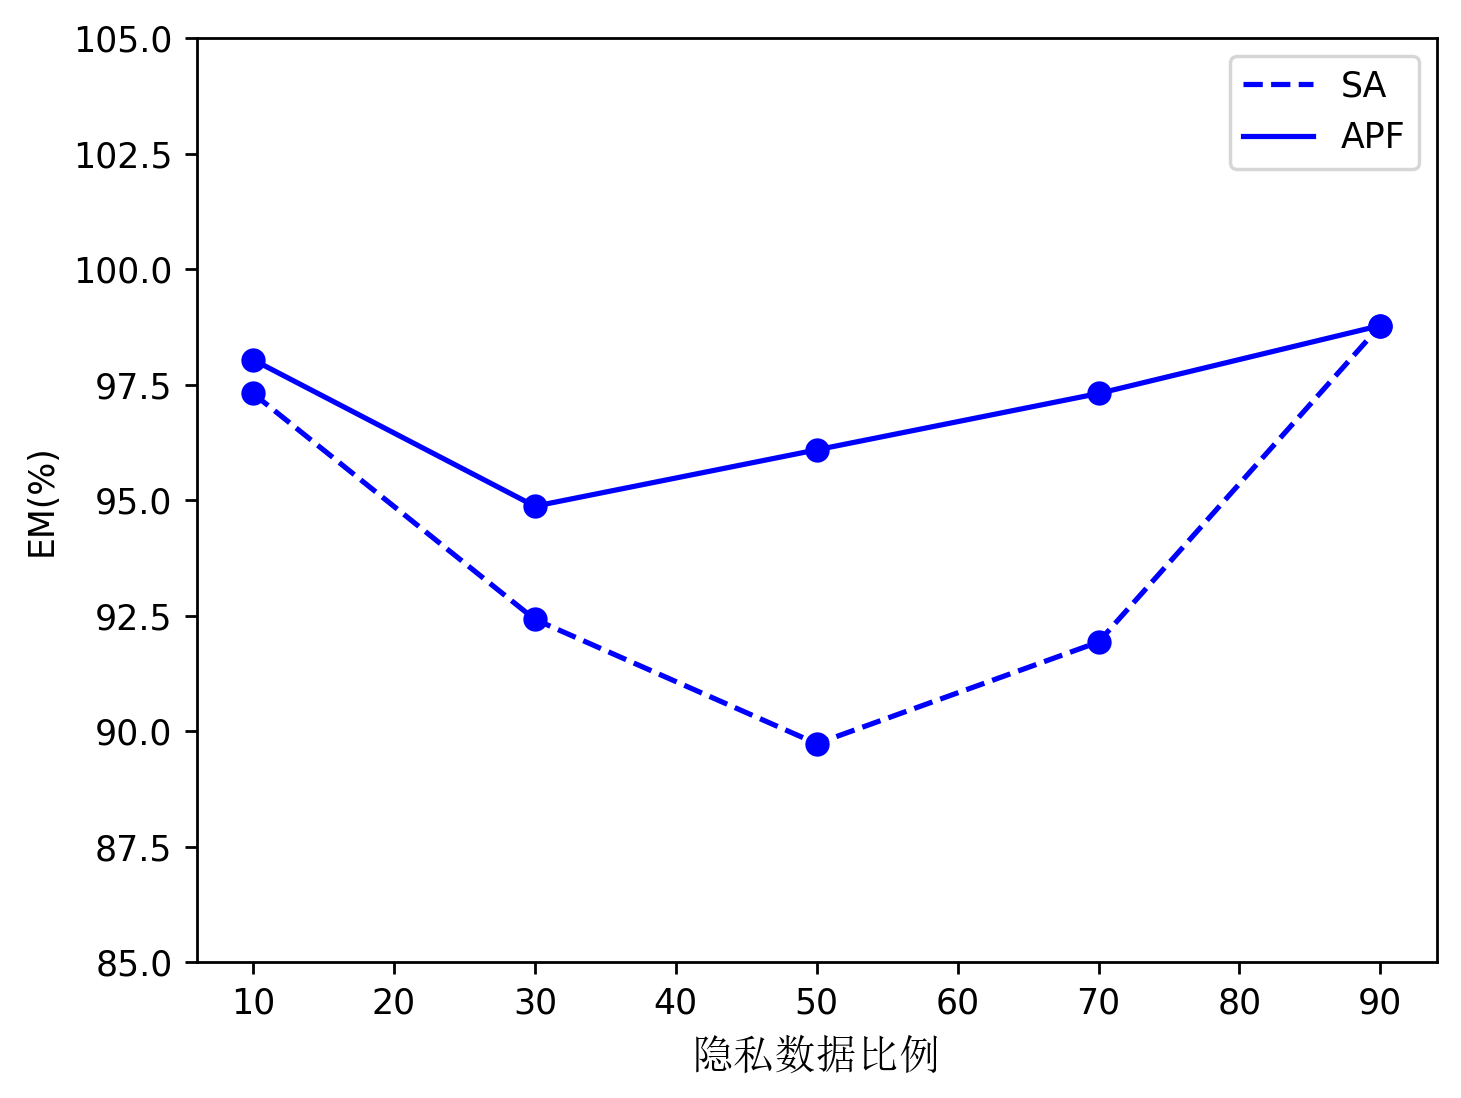

In [1]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_TQA_K10_noadapt = (
    np.array([0.97310513, 0.92420538, 0.89731051, 0.9193154, 0.98777506]).round(4) * 100
)
EM_TQA_K10 = (
    np.array([0.9804401, 0.94865526, 0.9608802, 0.97310513, 0.98777506]).round(4) * 100
)
print(EM_TQA_K10 - EM_TQA_K10_noadapt)
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_TQA_K10_noadapt, color="blue", linestyle="--", label="SA")
plt.scatter(x, EM_TQA_K10_noadapt, color="blue")
plt.plot(x, EM_TQA_K10, color="blue", label="APF")
plt.scatter(x, EM_TQA_K10, color="blue")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

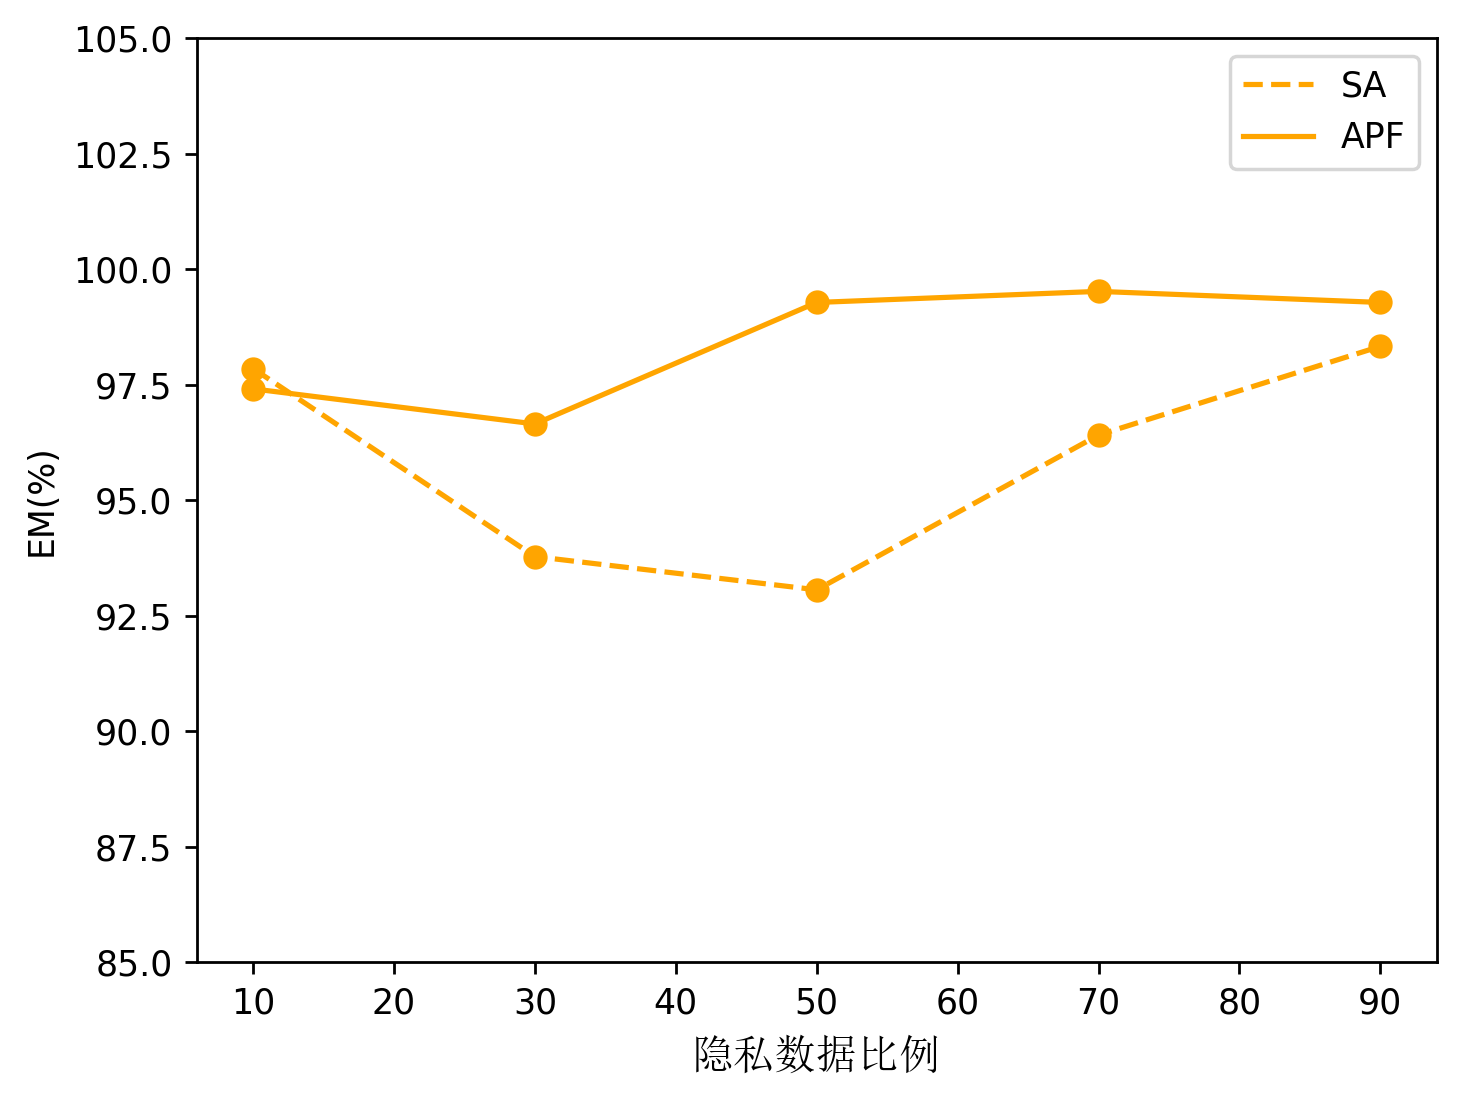

In [2]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_NQ_K10_noadapt = [97.85, 93.78, 93.06, 96.41, 98.33]
EM_NQ_K10 = [97.41, 96.65, 99.28, 99.52, 99.28]
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_NQ_K10_noadapt, color="orange", linestyle="--", label="SA")
plt.scatter(x, EM_NQ_K10_noadapt, color="orange")
plt.plot(x, EM_NQ_K10, color="orange", label="APF")
plt.scatter(x, EM_NQ_K10, color="orange")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

In [36]:
import json
import numpy as np


def fn():
    path1 = "../archive/ch3/is_adaptive_True.json"
    # path2 = "../tmp/native.json"
    # path1 = "../tmp/is_adaptive_True_k10_s100.json"
    path2 = "../tmp/native_k10_s100.json"
    fp = open(path1)
    data = json.load(fp)
    fp.close()
    dt = np.array(data["raw"]["cpu_DECODER"])
    et = np.array(data["raw"]["cpu_ENCODER"])
    prs = np.array(data["raw"]["pri_fusion_size"])
    rds = np.array(data["raw"]["required_dep_size"])
    tokens = np.array(data["raw"]["TOKENS_TEE"])
    sdt = np.array(data["raw"]["DECODER_TIMER"])
    fp = open(path2)
    data = json.load(fp)
    fp.close()
    native_et = np.array(data["raw"]["cpu_ENCODER"])
    native_dt = np.array(data["raw"]["cpu_DECODER"])

    load_size = 100

    totaltime = dt + et
    totaltime_ = totaltime.reshape(2, 5, load_size).sum(-1)
    print(f"totaltime\n{(totaltime_ / totaltime_[0])[1].round(4) * 100}")
    native_totaltime = native_et + native_dt
    native_totaltime = np.broadcast_to(native_totaltime, (2, 5, load_size))
    native_totaltime_ = native_totaltime.sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")
    mask_ = rds.reshape(2, 5, load_size) > 0
    native_totaltime_ = np.where(mask_, native_totaltime, 0).sum(-1)
    totaltime_ = np.where(mask_, totaltime.reshape(2, 5, load_size), 0).sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")

    rds_ = rds.reshape(2, 5, load_size).sum(-1)
    print(f"rds\n{(rds_[1])}")

    et_ = et.reshape(2, 5, load_size).sum(-1)
    print(f"encodertime\n{et_}")
    print(f"encodertime\n{(et_ / et_[0])[1].round(4) * 100}")

    dt_ = dt.reshape(2, 5, load_size).sum(-1)
    print(f"decodertime\n{dt_}")
    print(f"decodertime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    mask_ = rds.reshape(2, 5, load_size) > 0
    dt_ = dt.reshape(2, 5, load_size)
    dt_ = np.where(mask_, dt_, 0).sum(-1)
    print(f"adpativetime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    tkcum_ = (tokens - 1).cumsum()
    tkcum_ = np.insert(tkcum_, 0, 0)[:-1]
    sdt_ = sdt[tkcum_].reshape(2, 5, load_size)
    mask_ = rds.reshape(2, 5, load_size) > 0
    sdt_ = np.where(mask_, sdt_, 0).sum(-1)
    print(f"sdt_\n{sdt_}")
    print(f"sdt_\n{(sdt_ / sdt_[0])[1].round(4) * 100}")


fn()

totaltime
[ 98.32 103.82 101.27 102.07 101.6 ]
totaltime
[[3.37 2.32 1.77 1.5  1.27]
 [3.42 2.23 1.75 1.46 1.25]]
totaltime
[[2.77 2.24 1.75 1.49 1.26]
 [2.72 2.1  1.71 1.44 1.24]]
rds
[ 26 115  91  42   9]
encodertime
[[14.39149857 28.92788339 41.09164143 52.65984797 63.88181162]
 [14.40049839 29.24853086 41.52828813 53.1536684  65.47787642]]
encodertime
[100.06 101.11 101.06 100.94 102.5 ]
decodertime
[[20.39995575 21.59037256 25.0120821  25.68694091 28.42791605]
 [19.80527401 23.20162773 25.41484737 26.8127501  28.31139922]]
decodertime
[ 97.08 107.46 101.61 104.38  99.59]
adpativetime
[105.62 115.3  101.99 108.77 102.89]
sdt_
[[0.67345476 3.46348882 5.40634513 4.20201182 1.12817883]
 [1.09316564 4.50726366 6.13834405 4.65229273 1.20062876]]
sdt_
[162.32 130.14 113.54 110.72 106.42]
